## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


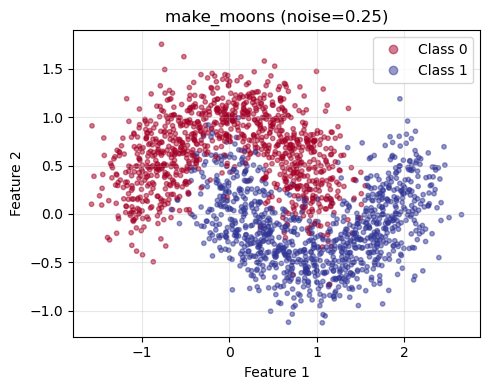

In [2]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
# Split the data into training and testing sets before scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    stratify = y)
# Scale the features using StandardScaler (zero mean, unit variance)
scaler = StandardScaler().fit(X_train)

# Scale both training and testing data using the same scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training observations : {len(X_train)}')
print(f'Test observations     : {len(X_test)}')

Training observations : 1400
Test observations     : 600


---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100




In [4]:
# Initialize the SVC model with a linear kernel 
svc = SVC(kernel = "linear",
    random_state = 42)

# Parameters to search over for the SVC model
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
    }

# Set up GridSearchCV to find the best hyperparameters for the SVC model
grid_linear_svc = GridSearchCV(
    estimator = svc,
    param_grid = param_grid,
        cv = 5, 
        scoring = "accuracy")

# Fit on training data
grid_linear_svc.fit(X_train_scaled, y_train)

# Print the best hyperparameters found by GridSearchCV
print(f"Best hyperparameters for SVC: {grid_linear_svc.best_params_}")
best_svc = grid_linear_svc.best_estimator_
print(f"Best SVC model: {best_svc}")

# Predict on the test set using the best SVC model
y_pred_svc = best_svc.predict(X_test_scaled)

# Calculate CV accuracy for the best SVC model
cv_acc = grid_linear_svc.best_score_
print(f"SVC CV Accuracy: {cv_acc:.4f}")

# Calculate and print the test accuracy for the SVC model
test_acc = accuracy_score(y_test, y_pred_svc)
print(f"SVC Test Accuracy: {test_acc:.4f}")

Best hyperparameters for SVC: {'C': 1}
Best SVC model: SVC(C=1, kernel='linear', random_state=42)
SVC CV Accuracy: 0.8600
SVC Test Accuracy: 0.8800


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [5]:

grid_linear_svc_results = pd.DataFrame(grid_linear_svc.cv_results_).sort_values(by="mean_test_score", ascending=False)[["param_C", "mean_test_score"]]
grid_linear_svc_results

,param_C,mean_test_score
3,1,0.860000
4,10,0.860000
5,100,0.860000
2,0.1,0.856429
1,0.01,0.853571
0,0.001,0.847143


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross-validation selected C=1 as the best value. I did not expect that the linear kernel would achieve a strong accuracy regardless of C because the moons boundary is curved. We are fitting a linear SVM to a dataset that has a non-linear decision boundary. After C=1 there is no further improvement in the accuracy.

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [6]:
# RBF kernel SVC
svc_rbf = SVC(kernel = 'rbf', random_state=42)

# Parameters to search over for the RBF SVC model
param_grid_rbf = {
    "C": [0.1, 1, 10, 100],
    "gamma": ['scale',0.001, 0.01, 0.1, 1, 10]
}

# Run GridSearchCV to find the best hyperparameters for the RBF SVC model
grid_rbf = GridSearchCV(
    estimator = svc_rbf,
    param_grid = param_grid_rbf,
        cv = 5, 
        scoring = "accuracy")

# Fit on training data
grid_rbf.fit(X_train_scaled, y_train)   

# Print the best hyperparameters found by GridSearchCV for the RBF SVC model
print(f"Best hyperparameters for RBF SVC: {grid_rbf.best_params_}")
print(f"Best RBF SVC CV Accuracy: {grid_rbf.best_score_:.4f}")

# Calculate and print the test accuracy for the best RBF SVC model
best_rbf = grid_rbf.best_estimator_
test_acc_rbf = accuracy_score(y_test, best_rbf.predict(X_test_scaled))
print(f"RBF SVC Test Accuracy: {test_acc_rbf:.4f}")



Best hyperparameters for RBF SVC: {'C': 1, 'gamma': 1}
Best RBF SVC CV Accuracy: 0.9479
RBF SVC Test Accuracy: 0.9383


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The RBF kernel improved performance over the linear SVM. The linear SVM achieved a best CV accuracy of 86.0% and a test accuracy of 88.0%, while the RBF SVM achieved a best CV accuracy of 94.8% and a test accuracy of 93.8%. This corresponds to an improvement of 8.8 percentage points in CV accuracy and 5.8 percentage points in test accuracy. The improvement is expected because the make_moons dataset has a non-linear decision boundary that the RBF kernel can capture more effectively than a linear SVM.

The best hyperparameters were C = 1 and γ = 1. Since gamma controls how quickly influence decays with distance, a value of 1 suggests a moderately flexible decision boundary rather than an extremely smooth or tightly fitted one. Together with C=1, the model seems to balance flexibility and generalization well, it fits the curve  of the data without overfitting.

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [7]:
# Polynomial kernel SVC
svc_poly = SVC(kernel = 'poly', random_state=42)

# Parameters to search over for the polynomial SVC model
param_grid_poly = {
      "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "degree": [2, 3, 4],
    "coef0": [0.0, 1.0]
}

# Run GridSearchCV to find the best hyperparameters for the polynomial SVC model    
grid_poly = GridSearchCV(
    estimator = svc_poly, 
    param_grid = param_grid_poly,
        cv = 5, 
        scoring = "accuracy"
)

# Fit on training data
grid_poly.fit(X_train_scaled, y_train)

# Print the best hyperparameters found by GridSearchCV for the polynomial SVC model
print(f"Best hyperparameters for polynomial SVC: {grid_poly.best_params_}")
print(f"Best polynomial SVC CV Accuracy: {grid_poly.best_score_:.4f}")

# Calculate and print the test accuracy for the best polynomial SVC model
best_poly = grid_poly.best_estimator_
test_acc_poly = accuracy_score(y_test, best_poly.predict(X_test_scaled))
print(f"Polynomial SVC Test Accuracy: {test_acc_poly:.4f}") 

Best hyperparameters for polynomial SVC: {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
Best polynomial SVC CV Accuracy: 0.9450
Polynomial SVC Test Accuracy: 0.9400


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

The grid search selected a degree 3 polynomial kernel. The polynomial SVM achieved 94.5% CV accuracy and 94.0% test accuracy, which is nearly identical to the RBF SVM (94.8% CV, 93.8% test). Both kernels performed very well on the curve-shaped data and significantly better than the linear SVM.

A higher degree does not always help because it makes the decision boundary more complex and can lead to overfitting. It seems like degree 3 polynomial provided the best balance between flexibility and generalization.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [8]:
param_grid_all = [

{   'kernel': ['linear'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
},

{
    'kernel': ['rbf'],
    'gamma': ['scale',0.001, 0.01, 0.1, 1, 10], # scale means 1 over the number of features times the variance of X
    'C': [0.1, 1, 10, 100]
},

{
    'kernel': ['poly'],
    'C' : [0.1, 1, 10, 100],   
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'degree': [2,3,4],
    'coef0': [0, 1]
}
    ]

grid_overall = GridSearchCV(
    estimator = SVC(random_state=42),
    param_grid = param_grid_all,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

# Fit the grid search on the training data to find the best overall SVC model
grid_overall.fit(X_train_scaled, y_train) 

# Get the best overall SVC model from the grid searchresults
best_overall = grid_overall.best_estimator_

# Predict on the test set using the best overall SVC model and calculate test accuracy
test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_scaled))


print(f"CV overall Accuracy: {grid_overall.best_score_:.4f}")
print(f"Best hyperparameters: {grid_overall.best_params_}")
print(f"Test Accuracy: {test_acc_overall:.4f}")


CV overall Accuracy: 0.9479
Best hyperparameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Test Accuracy: 0.9383


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The search selected the RBF kernel with a C=1 and gamma = 1 as the best model. This is consistent with the individual kernel results. In those, the RBF kernel achieved the highest CV accuracy among all 3 SVM models. The polynomial kernel performed almost as well (94.5% CV accuracy), while the linear performed worse at 86% CV accuracy. This makes intuitive sense because the make_moons dataset has a crescent-shaped decision boundary and the RBF kernel measures similarity based on distance. Nearby observations have a stronger influence on one another than obs that are far apart. Because of this, the model can create a more flexibile boundary that follows the shape of the curve. The polynomial kernel came close, but RBF won. 

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [9]:
param_grid_rf = {
    'n_estimators' : [100,200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1,5,10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid = param_grid_rf,
    cv = 5, 
    scoring = "accuracy",
    n_jobs = -1   
)

# Fit the grid search for Random Forest on the training data
grid_rf.fit(X_train_scaled, y_train)

# Get the best hyperparameters for the Random Forest model using GridSearchCV results
best_rf = grid_rf.best_estimator_

# Calculate the test accuracy for the best Random Forest model
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))

print(f"CV overall Accuracy: {grid_rf.best_score_:.4f}")
print(f"Best hyperparameters: {grid_rf.best_params_}")
print(f"Test Accuracy: {test_acc_rf:.4f}")

CV overall Accuracy: 0.9464
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Test Accuracy: 0.9383


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The Random Forest test accuracy (93.8%), identical to the best SVM kernel (RBF), which also achieved a test accuracy of 93.8%. Both models are capable of handling non-linear decision boundaries, so it is not too shocking, but it is interesting that the accuracies are identical. 

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

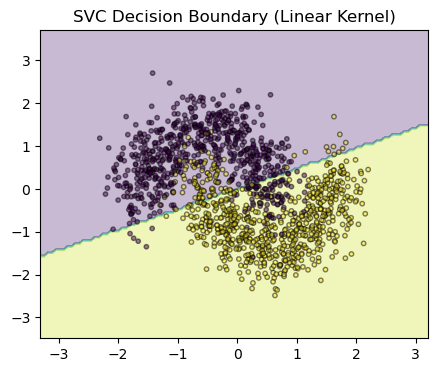

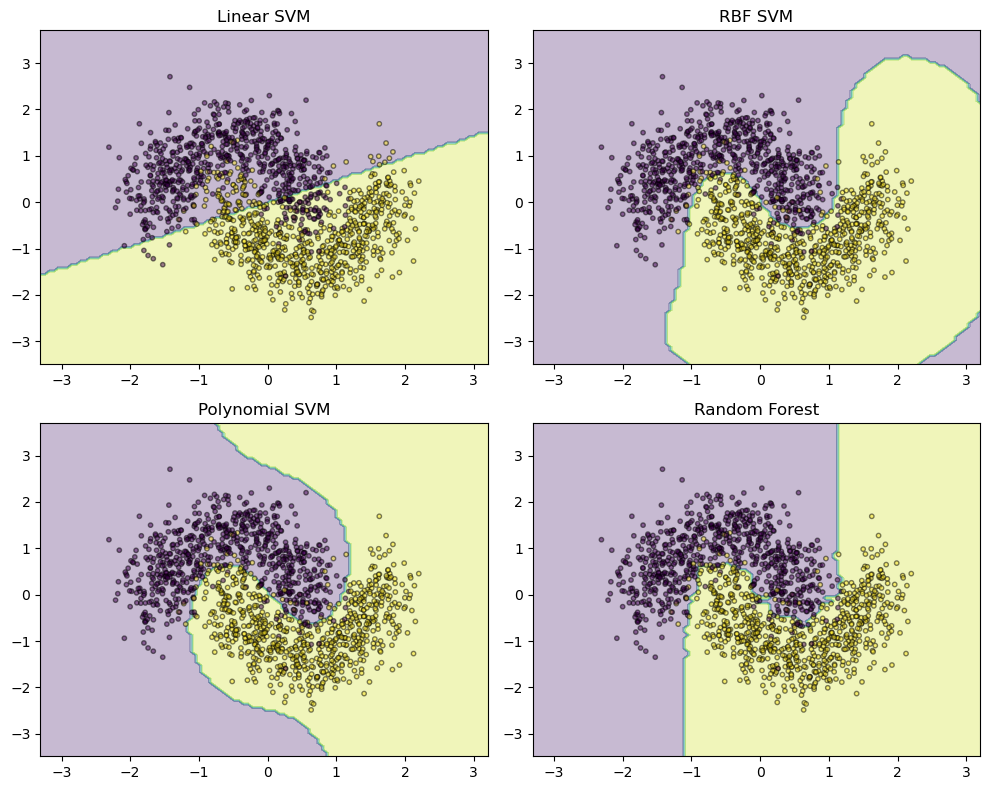

In [10]:
# Best Linear SVC Decision Boundary
fig, ax = plt.subplots(figsize=(5, 4))

DecisionBoundaryDisplay.from_estimator(grid_linear_svc, 
                                       X_train_scaled, 
                                       response_method="predict",
                                       ax=ax,
                                       alpha=0.3)
ax.scatter(X_train_scaled[:, 0],
            X_train_scaled[:, 1], 
            c=y_train, 
            edgecolor='k',
            s=10, alpha=0.5)

ax.set_title('SVC Decision Boundary (Linear Kernel)')
plt.show()

# All models

models = {
    "Linear SVM": best_svc,
    "RBF SVM": best_rbf,
    "Polynomial SVM": best_poly,
    "Random Forest": best_rf
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_scaled,
        response_method="predict",
        ax=ax,
        alpha=0.3
    )

    ax.scatter(
        X_train_scaled[:, 0],
        X_train_scaled[:, 1],
        c=y_train,
        edgecolor="k",
        s=10,
        alpha=0.5
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear SVM produces a single straight decision boundary and is can't follow the curved crescent shape of the data. More specifically, it goes through the points/ends of each crescent, instead of following their shape. It misclassifies more observations and performs worse than the other models. 

The RBF and polynomial SVMs both make non-linear boundaries that closely follow the moon shape. The RBF boundary appears more adaptive, it creates a flexible shape around the classes, while the polynomial boundary forms a stiffer S-curve as a result of the fixed the degree-3 polynomial form.

In contrast, the Random forest boundary has a different shape, comapred to the SVM boundaries. It curves, though not as smoothly, near the data, but then turns into a straight line on each end as it moves away from the data. Instead of creating blob-like shapes, it forms blocks. 

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

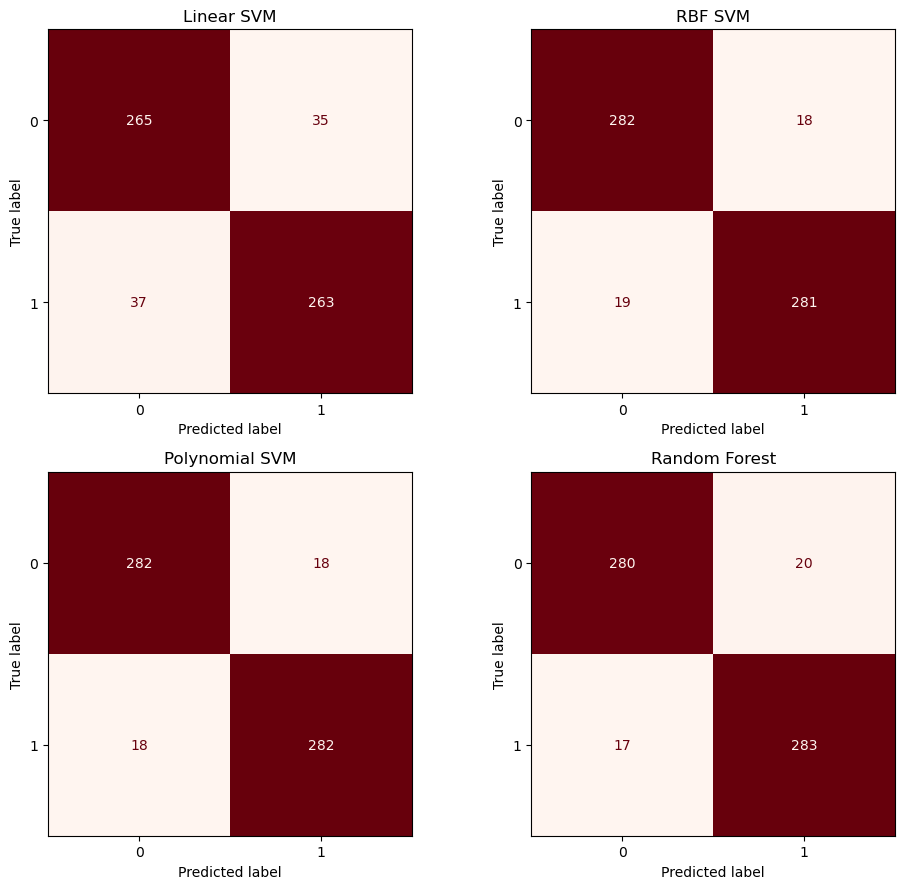

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        cmap='Reds',
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

All four models produced decently similar confusion matrices, with false positives and false negatives being nearly equal within each model, given that the dataset is made to be balanced between classes. The linear SVM had the most misclassifications (35 false positives, 37 false negatives, 72 total errors), which is consistent with the accuracy scores we saw earlier.

The RBF SVM (37 total errors), polynomial SVM (36 total errors), and Random Forest (37 total errors) performed very similarly and showed almost identical confusion matrices. I think most errors occur in the noisy overlap regions between the two crescents, where observations from the two classes are difficult to separate even with flexible non-linear models. Random forest seemed to struggle in that region in particular. 

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


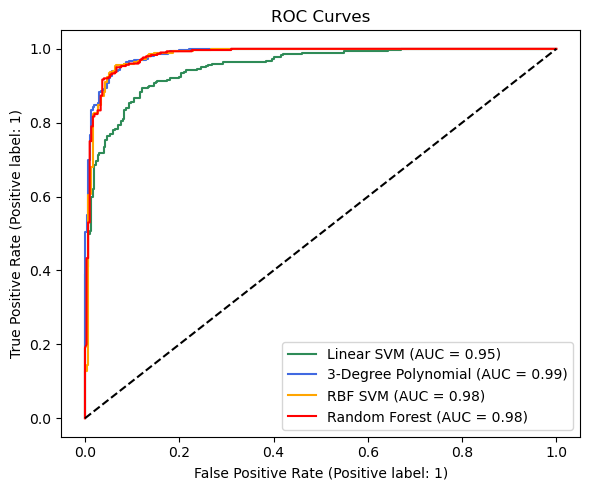

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

# ROC for linear model
RocCurveDisplay.from_estimator(best_svc, 
                               X_test_scaled, 
                               y_test, 
                               name = 'Linear SVM',
                               color = 'seagreen',
                               ax=ax)
RocCurveDisplay.from_estimator(best_poly, 
                               X_test_scaled, 
                               y_test, 
                               name = '3-Degree Polynomial',
                               color = 'royalblue',
                               ax=ax)
RocCurveDisplay.from_estimator(best_rbf, 
                               X_test_scaled, 
                               y_test, 
                               name = 'RBF SVM',
                               color = 'orange',
                               ax=ax)
RocCurveDisplay.from_estimator(best_rf, 
                               X_test_scaled, 
                               y_test, 
                               name = 'Random Forest',
                               color = 'red',
                               ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUC = 0.50)')
ax.set_title('ROC Curves')
plt.tight_layout()


> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

The AUC values match what we saw earlier in the confusion matrices and the accuracy scores. The liner SVM had the lowest accuracy, most misclassifications and lowest aUC (.95). The RBF SVM, poly SVM and Random Forest all had higher AUC Values (0.98, 0.98, 0.99), and fewer errors. The RBF, poly and Random Forest visibly cluster together in the ROC curve. 

The Random Forest performed similar to the RBF and polynomial SVMs across the 3 metrics. All 3 metrics had basically identical accuracy scores: accuracy, confusion matrix and AUC. 

If I had to choose one model for the data, I would pick the RBF SVM. The RBF SVM, polynomial SVM, and Random Forest all performed nearly identically on the test set. But, the CV accuracy is a more reliable measure of their performance, and RBF had the highest CV accuracy (0.948), compared to RF and polynomial. Same applies to the fact that the 3-Degree polynomial had a better AUC score (0.99) than RBF (0.98) - yes, the AUC score is higher for the polynomial, but it is the score for only from one test split and the difference is only 0.01. 


>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The linear kernel does not perform as well because it is restricted to a straight-line decision boundary, and the make_moons dataset has a curved, crescent-shaped structure. As long as the dataset is curve-shaped, a straight line will be a good boundary. It won't matter how much tuning we try. 

The RBF kernel, polynomial kernel, and Random Forest can all create non-linear decision boundaries. They follow the shape of the crescents and, therefore, correctly classify observations that the linear SVM could not. The RBF kernel measures similarity based on distance, the polynomial kernel uses a degree-3 curve, and the Random Forest creates the boundary using many decision-tree splits on. They create a decision boundary shape that approximates the shape of the data, delivering better AUC and accuracy scores. 